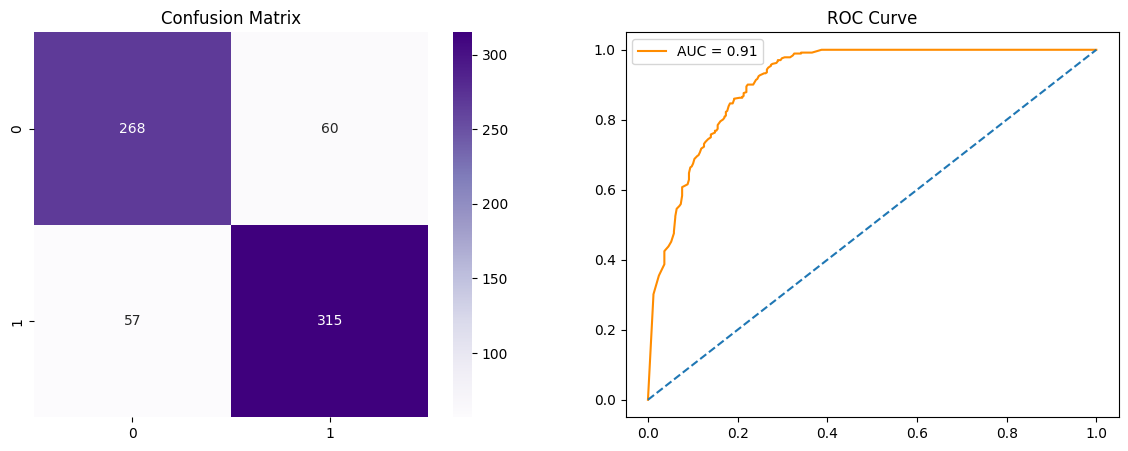

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your cleaned data
df = pd.read_csv('/content/ecommerce_sales_data.csv')

# 2. Create the Target Variable (1 for High Profit, 0 for Low Profit)
median_val = df['Profit'].median()
df['High_Profit'] = (df['Profit'] > median_val).astype(int)

# 3. Feature Selection & Encoding
# We convert text columns (Category, Region) into numbers the computer can read
X = df[['Category', 'Region', 'Quantity', 'Sales']]
y = df['High_Profit']

# Simple label encoding
X = pd.get_dummies(X, columns=['Category', 'Region'])

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluate and Visualize
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Create Visual Performance Report
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix: Shows how many we got right vs. wrong
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC Curve: Shows the model's ability to distinguish between classes
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='darkorange')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.show()